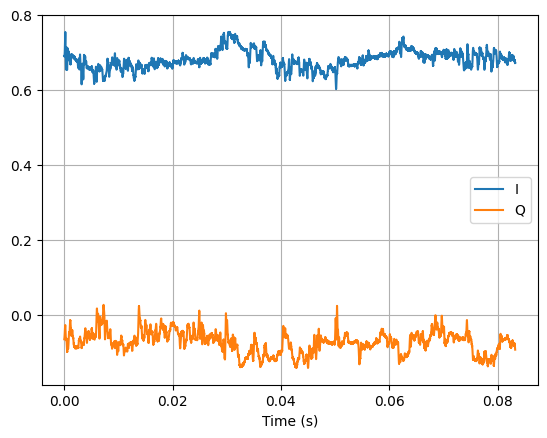

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# plot the average of the IQ profiles

filename = r"E:\data 06-04-2026 ucla\power62dB_Pressure_5660Torr_chirp9kHz-60kHz_IQ1"

data = np.loadtxt(filename, delimiter=",", usecols=(0, 1, 2))

t = data[:, 0]
I = data[:, 1]
Q = data[:, 2]

signal = I + 1j * Q
amplitude = np.abs(signal)
phase = np.angle(signal)

plt.figure()
plt.plot(t, I, label="I")
plt.plot(t, Q, label="Q")
plt.xlabel("Time (s)")
plt.legend()
plt.grid()
plt.show()

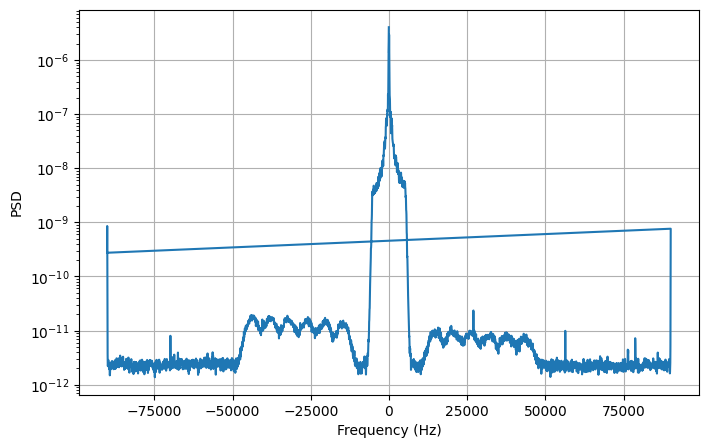

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import os

# --------------------------------------------------
# Parameters
# --------------------------------------------------

folder = r"E:\data 06-04-2026 ucla"

base = "power62dB_Pressure_5660Torr_chirp9kHz-60kHz_IQ"

Nfiles = 10   # number of files IQ1 ... IQ100

# --------------------------------------------------
# Read first file to determine sampling rate
# --------------------------------------------------

filename = os.path.join(folder, f"{base}1")

data = np.loadtxt(filename, delimiter=",", usecols=(0,1,2))

t = data[:,0]
I = data[:,1]
Q = data[:,2]

signal = I + 1j*Q

dt = np.mean(np.diff(t))
fs = 1/dt

# PSD of first file
freq, psd_sum = welch(
    signal,
    fs=fs,
    nperseg=4096,
    return_onesided=False
)

# --------------------------------------------------
# Loop over remaining files
# --------------------------------------------------

for j in range(2, Nfiles+1):

    filename = os.path.join(folder, f"{base}{j}")

    if not os.path.exists(filename):
        print(f"Missing file: {filename}")
        continue

    data = np.loadtxt(filename, delimiter=",", usecols=(0,1,2))

    I = data[:,1]
    Q = data[:,2]

    signal = I + 1j*Q

    _, psd = welch(
        signal,
        fs=fs,
        nperseg=4096,
        return_onesided=False
    )

    psd_sum += psd

# --------------------------------------------------
# Average PSD
# --------------------------------------------------

psd_avg = psd_sum / Nfiles

plt.figure(figsize=(8,5))
plt.semilogy(freq, psd_avg)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.grid(True)
plt.show()